QC filtering  biological + technical noise remove


# QC Logic

## 1. Low Gene Cells Remove

```python
adata = adata[adata.obs["nFeature_RNA"] >= 200]
```

Meaning:

```text
একটা cell-এ অন্তত 200 gene detect হতে হবে
```

Why?

যদি কোনো cell এ খুব কম gene detect হয়:

```text
50 genes
80 genes
120 genes
```

তাহলে usually:

* dead cell
* broken cell
* empty droplet
* sequencing artifact

হওয়ার chance বেশি।

---

# `nFeature_RNA` কী?

```text
Detected genes per cell
```

Example:

| Cell   | Genes detected |
| ------ | -------------- |
| Cell A | 3200           |
| Cell B | 180            |
| Cell C | 2400           |

এখানে Cell B suspicious।

---

# Visualization আগে কেন করেছিলে?

এই histogram:

```python
plt.hist(adata.obs["nFeature_RNA"])
```

এটা দেখে threshold decide করা হয়।

---

# 2. High Mitochondrial Cells Remove

```python
adata = adata[adata.obs["percent.mt"] < 20]
```

Meaning:

```text
mitochondrial RNA >20% হলে remove
```

---

# Why mitochondrial % important?

Dead/damaged cell এ:

```text
cytoplasmic RNA leak out
```

কিন্তু mitochondrial RNA বেশি stable থাকে।

তাই:

```text
High mt% = stressed/dead cell
```

---

# Example

| Cell | percent.mt |
| ---- | ---------- |
| A    | 3%         |
| B    | 8%         |
| C    | 42%        |

Cell C likely damaged.

---

# Typical thresholds

| Dataset           | Common mt threshold |
| ----------------- | ------------------- |
| PBMC              | 5-10%               |
| Tissue scRNA-seq  | 10-20%              |
| Kidney / Fibrosis | often 20%           |

Kidney injury datasets এ mt বেশি হতে পারে, তাই 20% reasonable।

---

# 3. Low Frequency Genes Remove

```python
sc.pp.filter_genes(adata, min_cells=3)
```

Meaning:

```text
যে gene অন্তত 3 cell এ নেই → remove
```

---

# Why?

Very rare genes হতে পারে:

* sequencing noise
* random artifact
* ambient contamination

---

# Example

| Gene       | Expressed in cells |
| ---------- | ------------------ |
| HAVCR1     | 12,000             |
| COL1A1     | 8,000              |
| RANDOM_XYZ | 1                  |

শেষেরটা useful না।

---

# Biological Meaning

QC এর goal:

```text
Keep:
✔ real cells
✔ biologically meaningful genes

Remove:
✘ dead cells
✘ broken cells
✘ empty droplets
✘ noise
✘ artifacts
```

---

# Visualization-driven QC

তুমি যেসব plot করেছো:

```text
nFeature_RNA histogram
nCount_RNA histogram
percent.mt histogram
scatter plots
```

এসব দেখে threshold tune করা হয়।

---


#   QC Pipeline

```text
Raw Matrix
↓
Remove low gene cells
↓
Remove high mitochondrial cells
↓
Remove rare genes
↓
QC-filtered dataset
```



In [1]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import mmread
from scipy import sparse

DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# =========================
# Load data
# =========================

genes = pd.read_csv(DATA_DIR / "genes.tsv", sep="\t", header=None)[0].astype(str)
barcodes = pd.read_csv(DATA_DIR / "barcodes.tsv", sep="\t", header=None)[0].astype(str)

counts = mmread(DATA_DIR / "counts.mtx")
if not sparse.issparse(counts):
    counts = sparse.coo_matrix(counts)

counts = counts.T.tocsr()

meta = pd.read_csv(
    DATA_DIR / "GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt",
    sep="\t",
    index_col=0,
    low_memory=False
)

adata = sc.AnnData(X=counts)
adata.var_names = genes.values
adata.obs_names = barcodes.values

common = adata.obs_names.intersection(meta.index)
adata = adata[common].copy()
adata.obs = meta.loc[common].copy()

print("Before QC:", adata)

# =========================
# QC Filtering
# =========================

adata.obs["percent.mt"] = pd.to_numeric(adata.obs["percent.mt"], errors="coerce")

# Filter cells
adata = adata[adata.obs["nFeature_RNA"] >= 200].copy()
adata = adata[adata.obs["percent.mt"] < 20].copy()

# Filter genes
sc.pp.filter_genes(adata, min_cells=3)

print("After QC:", adata)

# =========================
# Save QC data
# =========================

adata.write_h5ad(RESULTS_DIR / "GSE183276_QC_filtered.h5ad")

print("Saved:", RESULTS_DIR / "GSE183276_QC_filtered.h5ad")

Before QC: AnnData object with n_obs × n_vars = 109741 × 37080
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module'
After QC: AnnData object wit

QC-filtered data visualize

In [2]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = Path("results")
adata_path = RESULTS_DIR / "GSE183276_QC_filtered.h5ad"

adata = sc.read_h5ad(adata_path)

print("===== AnnData Summary =====")
print(adata)

print("\n===== obs columns / metadata =====")
print(list(adata.obs.columns))

print("\n===== var columns / gene metadata =====")
print(list(adata.var.columns))

print("\n===== layers =====")
print(list(adata.layers.keys()))

print("\n===== shape =====")
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)

print("\n===== first 5 cells metadata =====")
print(adata.obs.head())

print("\n===== first 10 genes =====")
print(adata.var.head(10))

===== AnnData Summary =====
AnnData object with n_obs × n_vars = 46720 × 28015
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module'
    var: 'n_

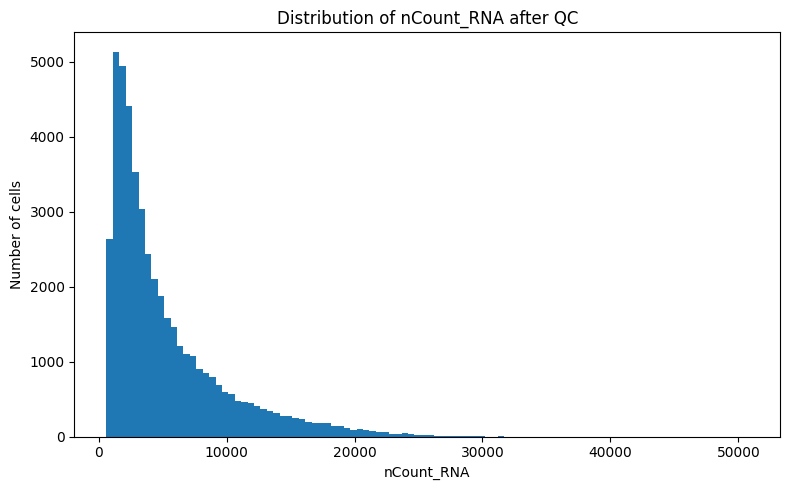

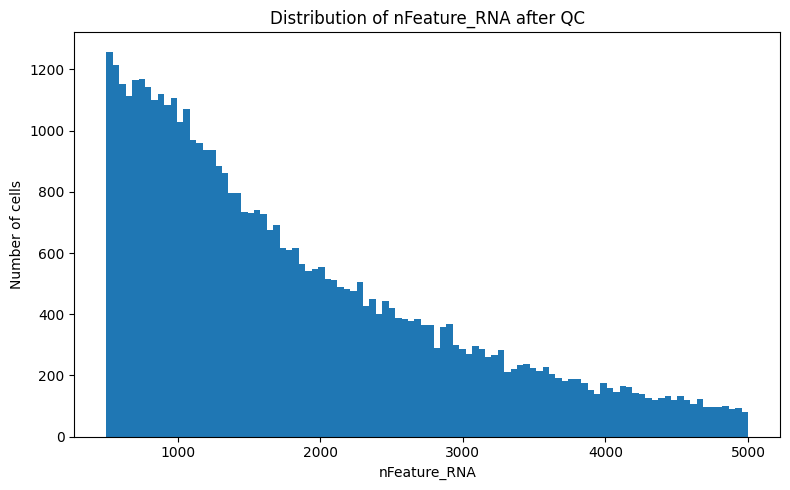

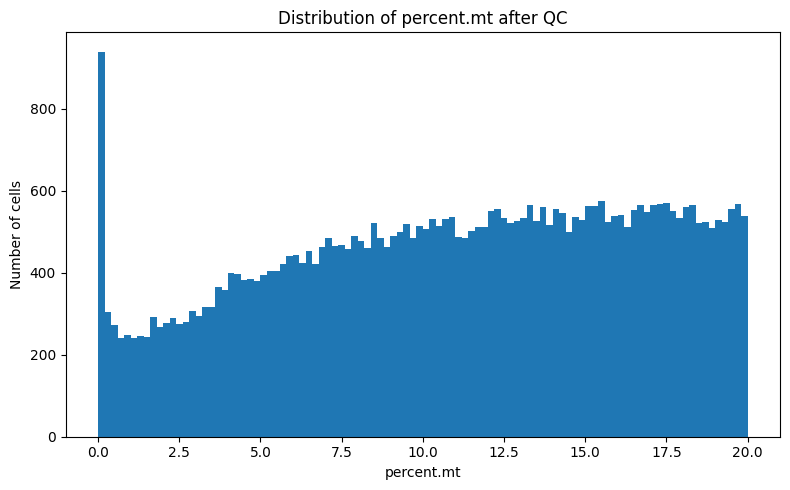

In [3]:
# ------------------------------
# 1. QC metric distribution
# ------------------------------

qc_cols = ["nCount_RNA", "nFeature_RNA", "percent.mt"]

for col in qc_cols:
    if col in adata.obs.columns:
        plt.figure(figsize=(8, 5))
        plt.hist(pd.to_numeric(adata.obs[col], errors="coerce"), bins=100)
        plt.xlabel(col)
        plt.ylabel("Number of cells")
        plt.title(f"Distribution of {col} after QC")
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"QC_filtered_{col}.png", dpi=300)
        plt.show()

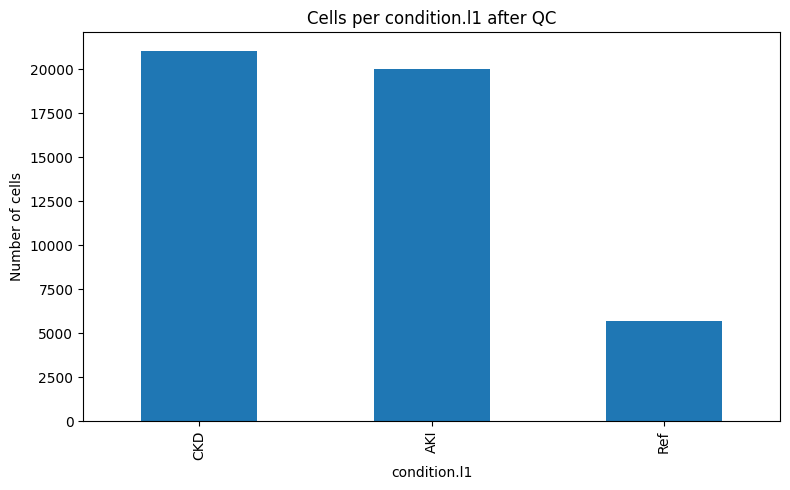

In [5]:
# ------------------------------
# 2. Condition distribution
# ------------------------------

for col in ["condition.l1"]:
    if col in adata.obs.columns:
        plt.figure(figsize=(8, 5))
        adata.obs[col].value_counts().plot(kind="bar")
        plt.xlabel(col)
        plt.ylabel("Number of cells")
        plt.title(f"Cells per {col} after QC")
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"QC_filtered_{col}.png", dpi=300)
        plt.show()

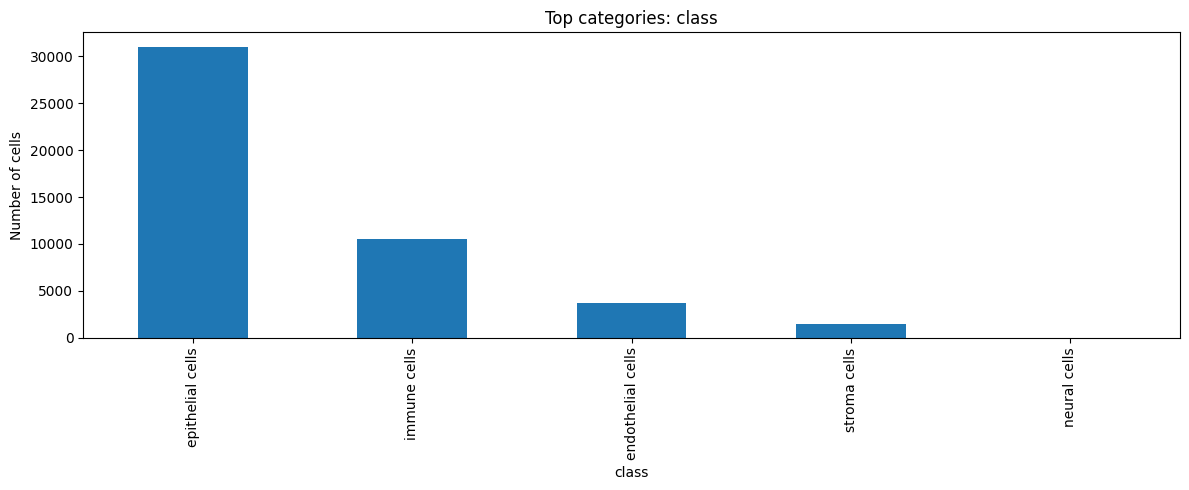

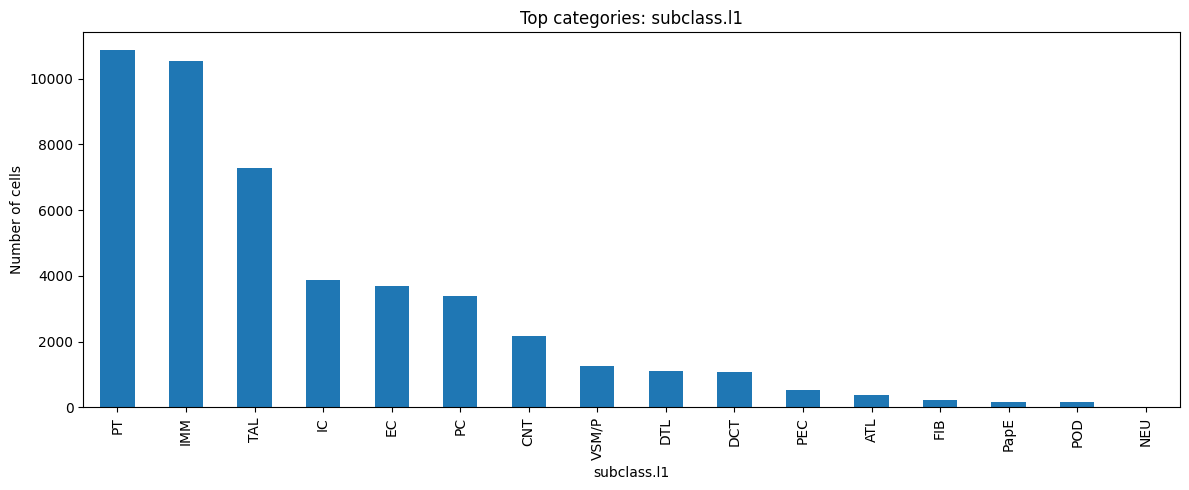

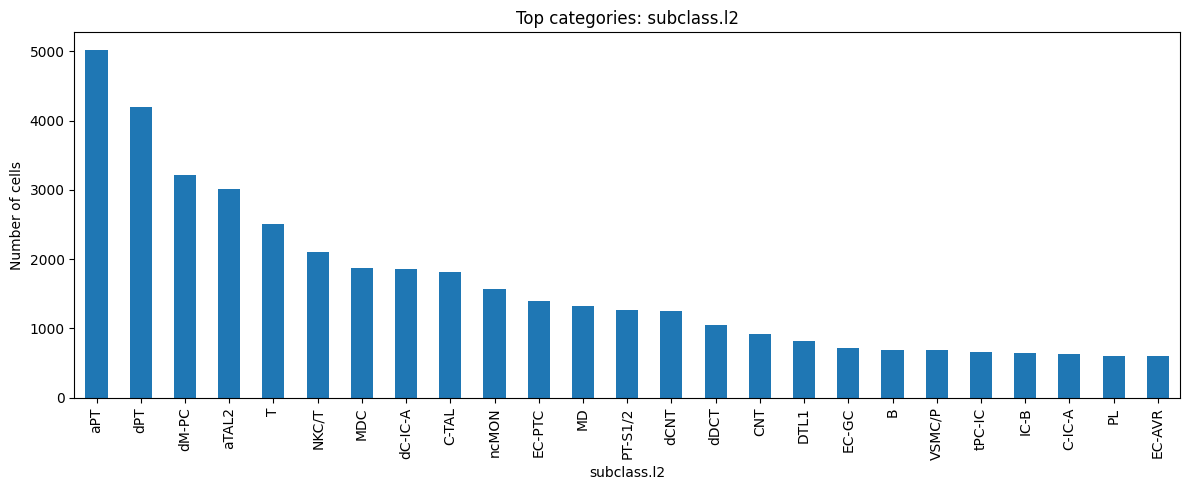

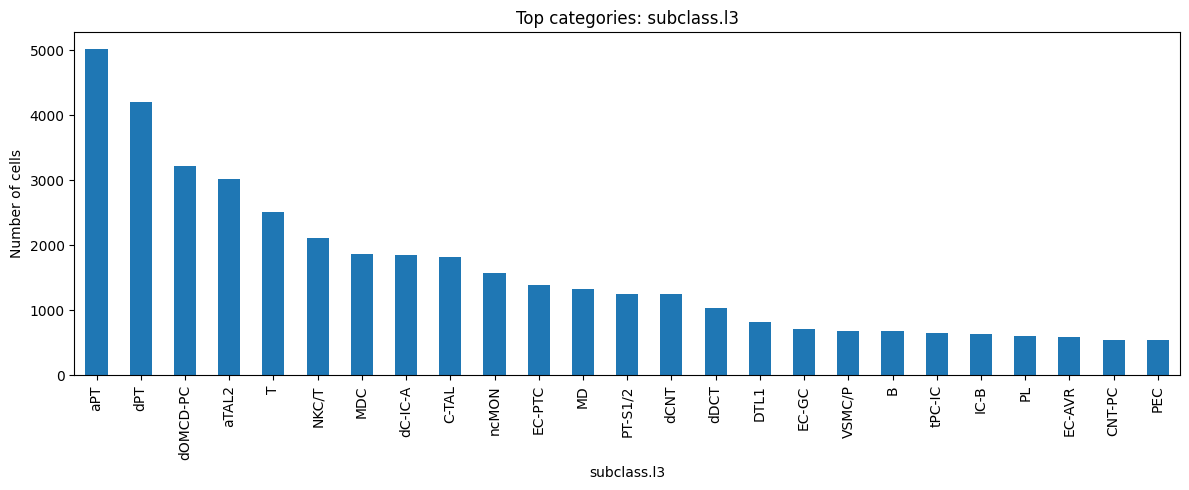

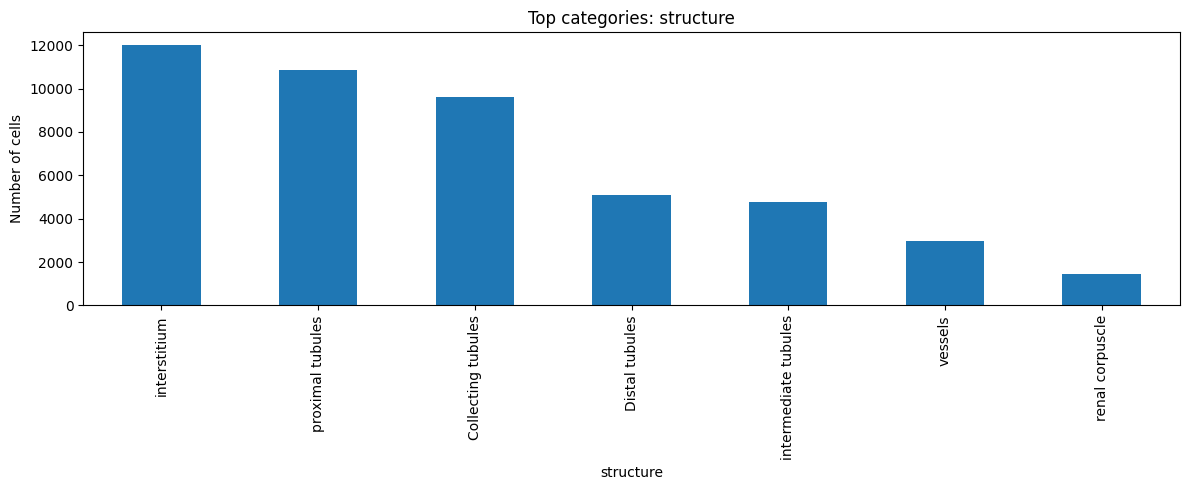

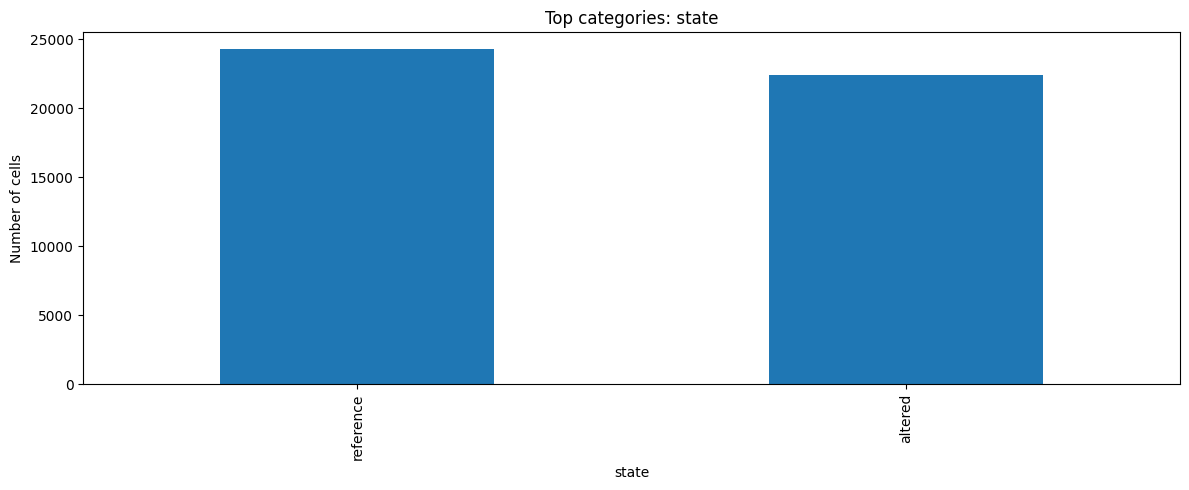

In [6]:
# ------------------------------
# 3. Cell type distribution
# ------------------------------

for col in ["class", "subclass.l1", "subclass.l2", "subclass.l3", "structure", "state"]:
    if col in adata.obs.columns:
        plt.figure(figsize=(12, 5))
        adata.obs[col].value_counts().head(25).plot(kind="bar")
        plt.xlabel(col)
        plt.ylabel("Number of cells")
        plt.title(f"Top categories: {col}")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"QC_filtered_{col}.png", dpi=300)
        plt.show()

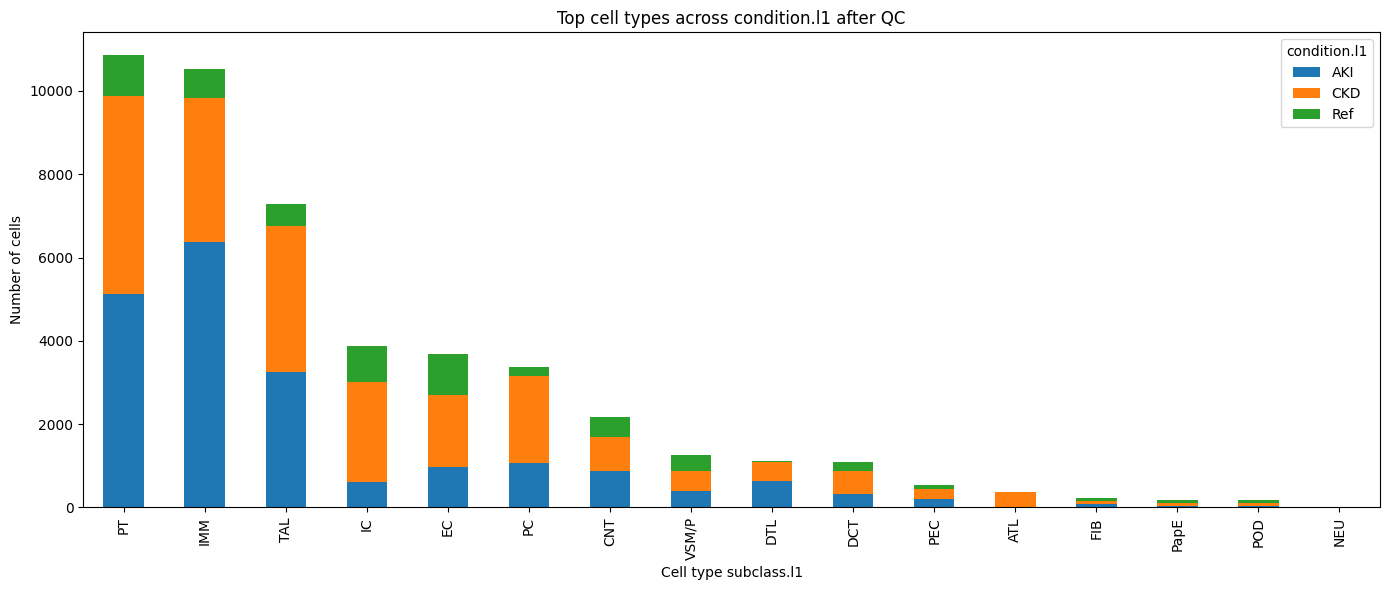

In [7]:
# ------------------------------
# 4. Condition vs cell type
# ------------------------------

if "condition.l1" in adata.obs.columns and "subclass.l1" in adata.obs.columns:
    cross = pd.crosstab(
        adata.obs["subclass.l1"],
        adata.obs["condition.l1"]
    )

    cross = cross.loc[cross.sum(axis=1).sort_values(ascending=False).head(20).index]

    cross.plot(kind="bar", stacked=True, figsize=(14, 6))
    plt.xlabel("Cell type subclass.l1")
    plt.ylabel("Number of cells")
    plt.title("Top cell types across condition.l1 after QC")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "QC_filtered_condition_vs_celltype.png", dpi=300)
    plt.show()

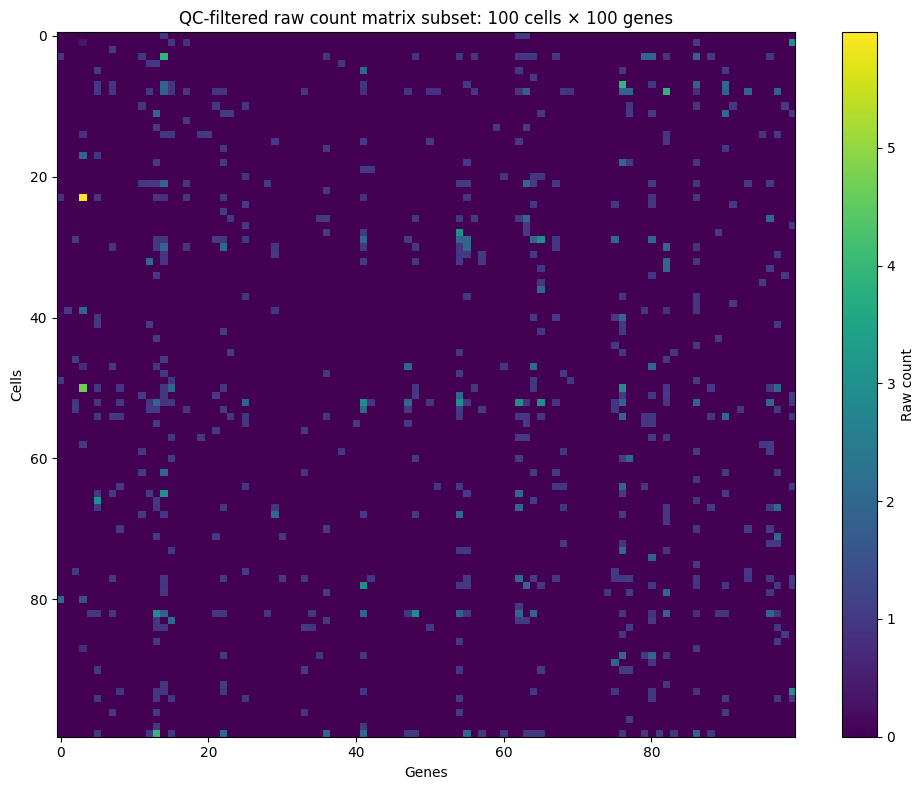

In [8]:
# ------------------------------
# 5. Small raw matrix view
# ------------------------------

small = adata.X[:100, :100]

if hasattr(small, "toarray"):
    small = small.toarray()

plt.figure(figsize=(10, 8))
plt.imshow(small, aspect="auto")
plt.colorbar(label="Raw count")
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.title("QC-filtered raw count matrix subset: 100 cells × 100 genes")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "QC_filtered_raw_matrix_100x100.png", dpi=300)
plt.show()

          gene   total_count
12497   MALAT1  5.320788e+06
21981   MT-CO1  4.873890e+06
21982   MT-CO2  4.379438e+06
21986   MT-ND3  3.703127e+06
21985   MT-CO3  2.880559e+06
21984  MT-ATP6  2.519986e+06
21988   MT-ND4  2.450335e+06
21991   MT-CYB  1.628356e+06
10459     IGKC  1.611995e+06
16615    RPL41  1.583102e+06
9021       FTL  1.522854e+06
7843    EEF1A1  1.415770e+06
16809   S100A6  1.367174e+06
21980   MT-ND2  1.229158e+06
7325     DEFB1  1.161408e+06
4720       B2M  1.129737e+06
9020      FTH1  1.126010e+06
16624    RPLP1  1.114426e+06
16573    RPL10  1.080178e+06
16643    RPS12  1.061682e+06
20562    WFDC2  1.004952e+06
16650    RPS18  1.000502e+06
16577    RPL13  9.508109e+05
21979   MT-ND1  9.479434e+05
19549     TPT1  9.068673e+05
19375   TMSB4X  8.913073e+05
16663    RPS28  8.823516e+05
16612    RPL39  8.723695e+05
18155     SPP1  8.710246e+05
19370   TMSB10  8.570849e+05


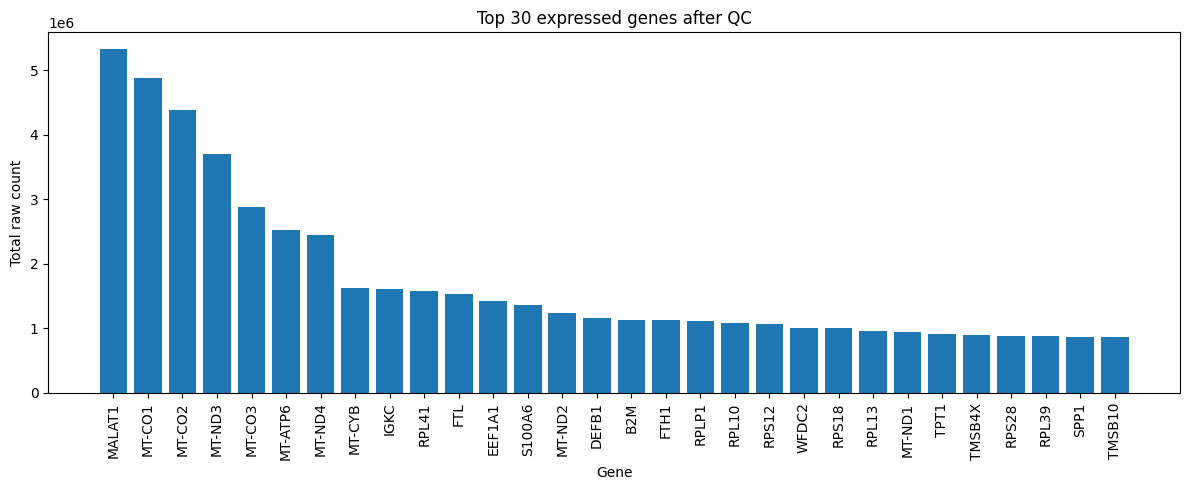

In [9]:
# ------------------------------
# 6. Top expressed genes
# ------------------------------

gene_sum = np.asarray(adata.X.sum(axis=0)).ravel()

top_genes = pd.DataFrame({
    "gene": adata.var_names,
    "total_count": gene_sum
}).sort_values("total_count", ascending=False).head(30)

print(top_genes)

plt.figure(figsize=(12, 5))
plt.bar(top_genes["gene"], top_genes["total_count"])
plt.xticks(rotation=90)
plt.xlabel("Gene")
plt.ylabel("Total raw count")
plt.title("Top 30 expressed genes after QC")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "QC_filtered_top_30_genes.png", dpi=300)
plt.show()